In [2]:
#================================================================================
#
# Name: machine-learning-sarimax-gdp.ipynb
#
# Description: Predict GDP using SARIMAX
#
# Author: MT
# 
# Date: 2025-11-15
# 
# Steps:
# Step 0: Import Libraries
# Step 1a: Read Data - Quarterly National Accounts GDP Data
# Step 1b: Read Data - Labour Market Statistics Data
# Step 1c: Merge DataFrames
# Step 2: Prepare Data
# Step 3: Visualise Data
# Step 4: Augmented Dickey-Fuller (ADF) Test
# Step 5: Build SARIMAX Model
# Step 6: Results
# Step 7: Forecast
# 
#================================================================================

In [3]:
#================================================================================
# Step 0: Import Libraries

#--------------------
# Pandas and Numpy
import pandas as pd
import numpy as np
import copy
#--------------------

#--------------------
# Plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
#--------------------

#--------------------
# Modeling
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
#--------------------
#================================================================================

In [4]:
#================================================================================
# Step 1a: Read Data - Quarterly National Accounts GDP Data

# Source: Office for National Statistics (ONS) UK
# https://www.ons.gov.uk/economy/grossdomesticproductgdp/datasets/quarterlynationalaccounts
# CDID = Title
# ABMI = Gross Domestic Product: chained volume measures: Seasonally adjusted £m	

# Keeps
keeps=[
'Title',
'Gross Domestic Product: chained volume measures: Seasonally adjusted £m',
]

# Column renames
renames={
'Title':'Date',
'Gross Domestic Product: chained volume measures: Seasonally adjusted £m':'GDPLevel',
}

# Read CSV
df_qna = pd.read_csv('qna.csv')[keeps].rename(columns=renames)

# Convert to numeric
df_qna['GDPLevel'] = pd.to_numeric(df_qna['GDPLevel'], errors='coerce')

# Retain non-missing data
mask = (df_qna['Date'].str.contains('Q') & df_qna['GDPLevel'].notna())
df_qna=df_qna[mask]
#================================================================================

In [5]:
#================================================================================
# Step 1b: Read Data - Labour Market Statistics Data

# Source: Office for National Statistics (ONS) UK
# https://www.ons.gov.uk/employmentandlabourmarket/peopleinwork/employmentandemployeetypes/datasets/labourmarketstatistics
# CDID = Title
# MGSX = Unemployment rate (aged 16 and over, seasonally adjusted): %

# Keeps
keeps=[
'Title',
'Unemployment rate (aged 16 and over, seasonally adjusted): %',
]

# Column renames
renames={
'Title':'Date',
'Unemployment rate (aged 16 and over, seasonally adjusted): %':'UnempRate',
}

# Read CSV
df_lms = pd.read_csv('lms.csv', low_memory=False)[keeps].rename(columns=renames)

# Convert to numeric
df_lms['UnempRate'] = pd.to_numeric(df_lms['UnempRate'], errors='coerce')

# Retain non-missing data
mask = (df_lms['Date'].str.contains('Q') & df_lms['UnempRate'].notna())
df_lms=df_lms[mask]
#================================================================================

In [6]:
#================================================================================
# Step 1c: Merge DataFrames
df=pd.merge(df_qna, df_lms, on='Date', how='inner').reset_index(drop=True)
df
#================================================================================

,Date,GDPLevel,UnempRate
0,1971 Q1,233843.0,3.8
1,1971 Q2,238030.0,4.1
2,1971 Q3,242078.0,4.2
3,1971 Q4,243009.0,4.4
4,1972 Q1,243540.0,4.5
...,...,...,...
213,2024 Q2,695793.0,4.2
214,2024 Q3,697153.0,4.3
215,2024 Q4,698832.0,4.4
216,2025 Q1,703458.0,4.5


In [7]:
#================================================================================
# Step 2: Prepare Data

# Create a deep copy of the original dataframe to avoid modifying it directly
df2 = copy.deepcopy(df)

# Extract the year from the 'Date' column
df2['Y'] = df2['Date'].str[:4]

# Extract the quarter number, convert it to the corresponding month, and cast it to string
df2['M'] = (df2['Date'].str[-1].astype(int) * 3).astype('str')
# Combine the year and month into a single string and convert it to a datetime object
df2['date'] = df2['Y'] + '-' + df2['M'] + '-01'
df2['date'] = pd.to_datetime(df2['date'], format='%Y-%m-%d') + pd.offsets.MonthEnd(0)

# Convert the datetime object to a date object
df2['date'] = df2['date'].dt.date

# Keep necessary columns
df2 = df2[['date', 'GDPLevel', 'UnempRate']]

# Calculate the year-over-year growth rate (percentage change over 4 quarters)
df2['GDPGrowth'] = round(df2['GDPLevel'].pct_change(4)*100,6)
df2['UnempRateGrowth'] = round(df2['UnempRate'].pct_change(4)*100,6)

# Drop the first 4 rows with NaN values in the 'Growth' column
mask = df2['date'] >= pd.Timestamp('1975-01-01').date()
df2 = df2[mask]

df2.reset_index(drop=True, inplace=True)

# Display the resulting dataframe
df2
#================================================================================

,date,GDPLevel,UnempRate,GDPGrowth,UnempRateGrowth
0,1975-03-31,258116.0,4.0,0.563369,11.111111
1,1975-06-30,253935.0,4.3,-2.462867,19.444444
2,1975-09-30,253168.0,4.7,-3.330406,27.027027
3,1975-12-31,255985.0,5.0,-0.806383,35.135135
4,1976-03-31,260268.0,5.3,0.833734,32.500000
...,...,...,...,...,...
197,2024-06-30,695793.0,4.2,0.914008,0.000000
198,2024-09-30,697153.0,4.3,1.354096,4.878049
199,2024-12-31,698832.0,4.4,1.925826,12.820513
200,2025-03-31,703458.0,4.5,1.745911,4.651163


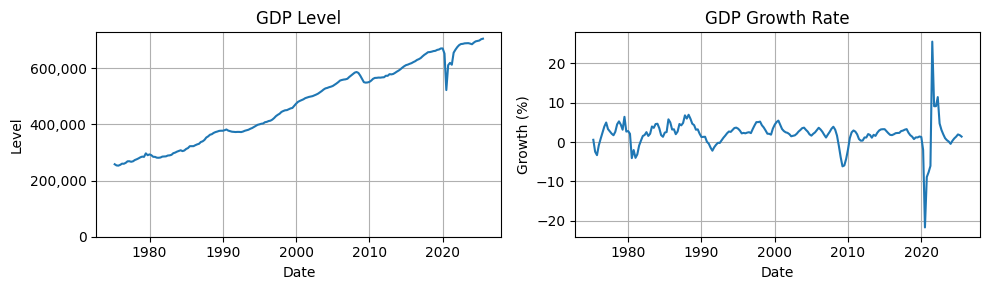

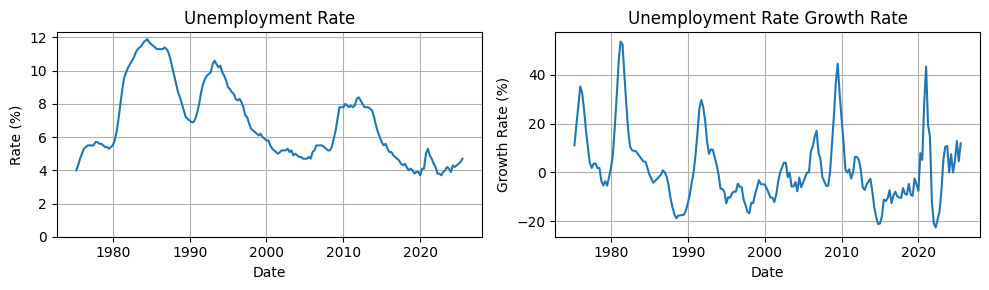

In [8]:
#================================================================================
# Step 3: Visualise Data

#-----------------------
# GDP Level and Growth Rate
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# --- Panel 1: GDP Level ---
sns.lineplot(ax=axes[0], x='date', y='GDPLevel', data=df2)
axes[0].set_title('GDP Level')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Level')
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[0].set_ylim(bottom=0)
axes[0].grid(True)

# --- Panel 2: GDP Growth Rate ---
sns.lineplot(ax=axes[1], x='date', y='GDPGrowth', data=df2)
axes[1].set_title('GDP Growth Rate')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Growth (%)')
axes[1].grid(True)

plt.savefig("sarimax_gdp-growth.png", bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()
#-----------------------

#-----------------------
# UnempRate Level and Growth Rate
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# --- Panel 1: GDP Level ---
sns.lineplot(ax=axes[0], x='date', y='UnempRate', data=df2)
axes[0].set_title('Unemployment Rate')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Rate (%)')
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[0].set_ylim(bottom=0)
axes[0].grid(True)

# --- Panel 2: Unemployment Rate Growth Rate ---
sns.lineplot(ax=axes[1], x='date', y='UnempRateGrowth', data=df2)
axes[1].set_title('Unemployment Rate Growth Rate')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Growth Rate (%)')
axes[1].grid(True)

plt.savefig("sarimax_unemp-rate-growth.png", bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()
#-----------------------

#================================================================================

In [9]:
#================================================================================
# Step 4: Augmented Dickey-Fuller (ADF) Test

# Test stationarity using ADF test
# H0: The time series is non-stationary
# H1: The time series is stationary

# List of variables to test
variables = ['GDPLevel', 'GDPGrowth', 'UnempRate', 'UnempRateGrowth']

results = []

for var in variables:
    adf_stat, p_value, _, _, _, _ = adfuller(df2[var].dropna())
    
    decision = "Reject H0 (Stationary)" if p_value < 0.05 else "Do Not Reject H0 (Non-Stationary)"
    
    results.append({
        "Variable": var,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Decision": decision
    })

# Create DataFrame
adf_table = pd.DataFrame(results)
print(adf_table)
#================================================================================

          Variable  ADF Statistic   p-value                           Decision
0         GDPLevel      -0.322606  0.922241  Do Not Reject H0 (Non-Stationary)
1        GDPGrowth      -4.698089  0.000085             Reject H0 (Stationary)
2        UnempRate      -2.267050  0.182815  Do Not Reject H0 (Non-Stationary)
3  UnempRateGrowth      -3.010712  0.033906             Reject H0 (Stationary)


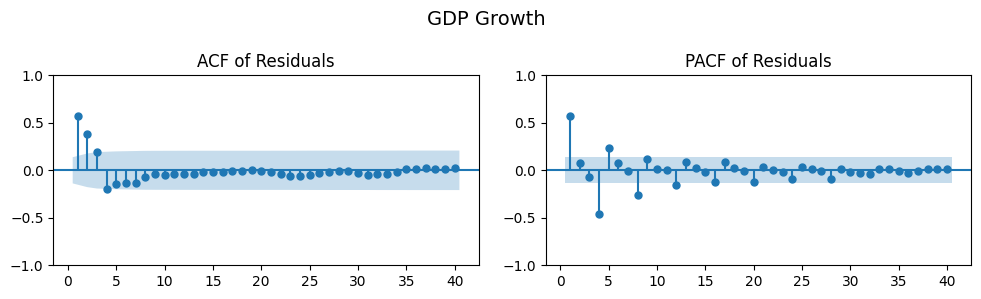

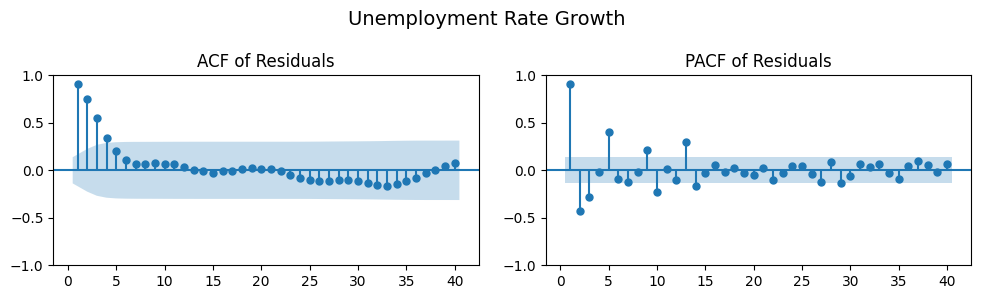

In [10]:
#================================================================================
# Step 4: Augmented Dickey-Fuller (ADF) Test

# Single panel with ACF and PACF side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle("GDP Growth", fontsize=14)
residuals = df2['GDPGrowth']
plot_acf(residuals, lags=40, ax=axes[0], title="ACF of Residuals", zero=False)
plot_pacf(residuals, lags=40, ax=axes[1], title="PACF of Residuals", zero=False)
plt.savefig("sarimax_gdp-acf-pacf.png", bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()

# Single panel with ACF and PACF side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle("Unemployment Rate Growth", fontsize=14)
residuals = df2['UnempRateGrowth']
plot_acf(residuals, lags=40, ax=axes[0], title="ACF of Residuals", zero=False)
plot_pacf(residuals, lags=40, ax=axes[1], title="PACF of Residuals", zero=False)
plt.savefig("sarimax_unemp-rate-acf-pacf.png", bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()
#================================================================================

                                     SARIMAX Results                                      
Dep. Variable:                          GDPGrowth   No. Observations:                  202
Model:             SARIMAX(1, 0, 1)x(2, 0, [], 4)   Log Likelihood                -437.565
Date:                            Sat, 15 Nov 2025   AIC                            889.130
Time:                                    20:04:26   BIC                            911.969
Sample:                                03-31-1975   HQIC                           898.379
                                     - 06-30-2025                                         
Covariance Type:                              opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept           0.6783      0.222      3.062      0.002       0.244       1.113
UnempRateGrowth    -

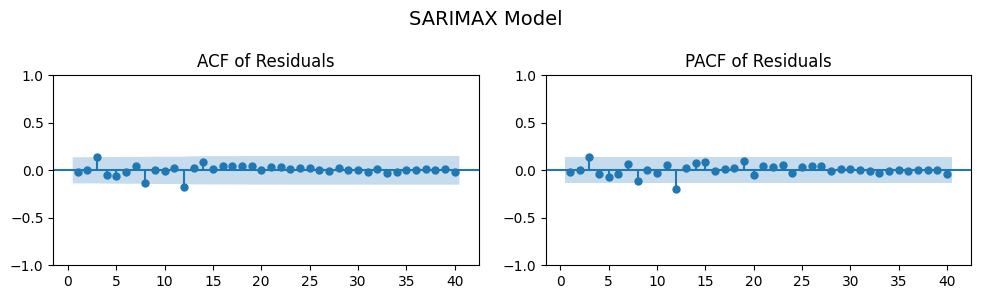

Ljung-Box Test Results:
      lb_stat  lb_pvalue
12  16.552532   0.167219
Decision: Do Not Reject H0 (Likely white noise)


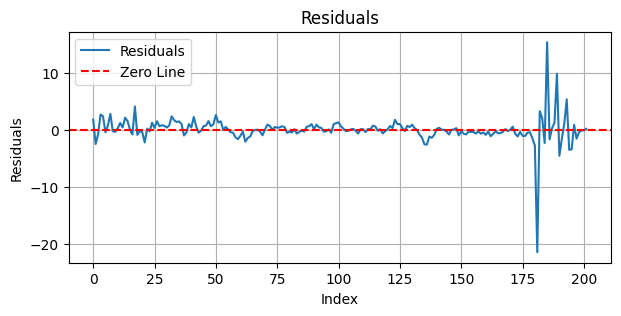

In [11]:
#================================================================================
# Step 5: Build SARIMAX Model

df3=copy.deepcopy(df2[['date','GDPGrowth', 'UnempRateGrowth', 'UnempRate']])
df3.set_index('date', inplace=True)
df3.index = pd.to_datetime(df3.index)  # Ensure the index is a datetime index
df3 = df3.asfreq('QE')

model = SARIMAX(df3['GDPGrowth'], 
                exog=df3['UnempRateGrowth'],
                order=(1, 0, 1),  # Non-seasonal ARIMA(p, d, q)
                seasonal_order=(2, 0, 0, 4),  # Seasonal ARIMA(P, D, Q, s)
                enforce_stationarity=False, 
                enforce_invertibility=False, 
                trend='c')  # Include intercept

# Fit the model
fitted_model = model.fit()

# Print the summary of the fitted model
print(fitted_model.summary())

# Get in-sample predictions
residuals = fitted_model.resid

# Get in-sample predictions
predicted_values = fitted_model.predict()

# Plot ACF and PACF of residuals
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle("SARIMAX Model", fontsize=14)
plot_acf(residuals, lags=40, ax=axes[0], title="ACF of Residuals", zero=False)
plot_pacf(residuals, lags=40, ax=axes[1], title="PACF of Residuals", zero=False)
plt.savefig("sarimax_model-acf-pacf.png", bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()

# Perform Ljung-Box test
# H0: The data are independently distributed (no autocorrelation up to the chosen lag)
# H1: The data are NOT independently distributed (there is autocorrelation up to the chosen lag)
ljung_box_results = acorr_ljungbox(residuals, lags=[12], return_df=True)
print("Ljung-Box Test Results:")
print(ljung_box_results)
decision = "Reject H0 (Not white noise)" if ljung_box_results['lb_pvalue'].iloc[0] < 0.05 else "Do Not Reject H0 (Likely white noise)"
print("Decision:", decision)

# Plot residuals using Seaborn
plt.figure(figsize=(7, 3))
sns.lineplot(x=range(len(residuals)), y=residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.title("Residuals")
plt.xlabel("Index")
plt.ylabel("Residuals")
plt.legend()
plt.savefig("sarimax_model-residuals.png", bbox_inches="tight", dpi=300)
plt.grid(True)
plt.show()
#================================================================================

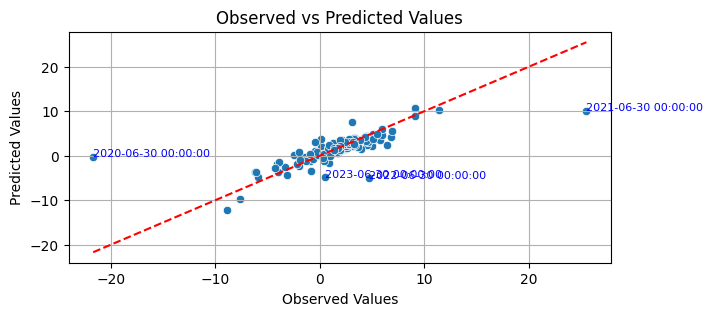

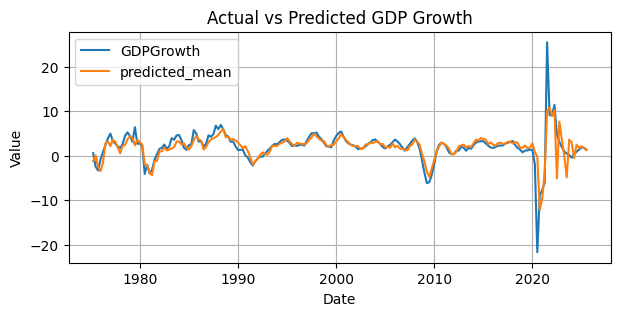

In [12]:
#================================================================================
# Step 6: Results
temp=pd.merge(left=df3.reset_index(), 
              right=pd.DataFrame(predicted_values).reset_index(),
              how='inner',
              left_on='date',
              right_on='date')

temp2=pd.merge(left=temp,
                right=pd.DataFrame(residuals).reset_index(),
                how='inner',
                left_on='date',
                right_on='date')
temp2.rename(columns={0:'Residuals'}, inplace=True)
temp2['q']=temp2['GDPGrowth']-temp2['predicted_mean']

plt.figure(figsize=(7, 3))
sns.scatterplot(data=temp2, x='GDPGrowth', y='predicted_mean')
plt.xlabel('Observed Values')
plt.ylabel('Predicted Values')
plt.title('Observed vs Predicted Values')

# Add a 45-degree line
min_val = min(temp2['GDPGrowth'].min(), temp2['predicted_mean'].min())
max_val = max(temp2['GDPGrowth'].max(), temp2['predicted_mean'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='45-degree line')

## Add data labels for specific points
#for i, row in temp2.iterrows():
#    if row['Growth'] > 8 or row['Growth'] <- 8:
#        plt.text(row['Growth'], row['predicted_mean'], 
#                 f"{row['date']}",  # Display the date
#                 fontsize=8, color='blue')

# Add data labels for specific points
for i, row in temp2.iterrows():
    if row['Residuals'] > 5 or row['Residuals'] <-5:
        plt.text(row['GDPGrowth'], row['predicted_mean'], 
                 f"{row['date']}",  # Display the date
                 fontsize=8, color='blue')
plt.savefig("sarimax_model-scatter.png", bbox_inches="tight", dpi=300)
plt.grid(True)
plt.show()

# Plot using Seaborn
plt.figure(figsize=(7, 3))
sns.lineplot(x='date', y='GDPGrowth', data=temp2, label='GDPGrowth')
sns.lineplot(x='date', y='predicted_mean', data=temp2, label='predicted_mean')
plt.title('Actual vs Predicted GDP Growth')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.savefig("sarimax_model-actual-vs-predicted.png", bbox_inches="tight", dpi=300)
plt.grid(True)
plt.show()
#================================================================================

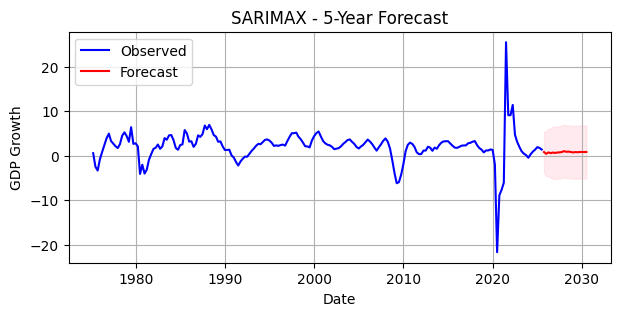

In [13]:
#================================================================================
# Step 7: Forecast

# Forecast the next 20 quarters
forecast_steps = 20

# Flat future forecast for exogenous variable
forecast_index = pd.date_range(
    start=df3.index[-1] + pd.offsets.QuarterEnd(0),
    periods=forecast_steps,
    freq='QE')
last_gdp_growth = df3['UnempRateGrowth'].iloc[-1]
future_exog = pd.DataFrame(
    {'UnempRateGrowth': np.repeat(last_gdp_growth, forecast_steps)},
    index=forecast_index)

# Generate forecast
forecast = fitted_model.get_forecast(steps=forecast_steps, exog=future_exog)

# Get confidence intervals for the forecast
conf_int = forecast.conf_int()

# Create a DataFrame for the forecasted values
forecast_index = pd.date_range(start=df3.index[-1], periods=forecast_steps + 1, freq='QE')[1:]
forecast_df = pd.DataFrame({
    'Forecast': forecast.predicted_mean,
    'Lower Bound': conf_int.iloc[:, 0],
    'Upper Bound': conf_int.iloc[:, 1]
}, index=forecast_index)

# Plot the forecast
plt.figure(figsize=(7, 3))
plt.plot(df3.index, df3['GDPGrowth'], label='Observed', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='red')
plt.fill_between(forecast_df.index, forecast_df['Lower Bound'], forecast_df['Upper Bound'], color='pink', alpha=0.3)
plt.title('SARIMAX - 5-Year Forecast')
plt.xlabel('Date')
plt.ylabel('GDP Growth')
plt.legend()
plt.savefig("sarimax_model-forecast.png", bbox_inches="tight", dpi=300)
plt.grid(True)
plt.show()
#================================================================================